# Bayesian Inference — Linear Model with Measurement Errors
### Advanced Data Laboratory
#### Edwin Leonardo Pérez Ochoa - PhD Student Universidad de Guanajuato
### True line: Y = -0.91 X + 4.0

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import corner

TRUE_M, TRUE_B = -0.91, 4.0
rng = np.random.default_rng(42)

## 1. Load data (rows: x, y, sigy)

In [5]:
def load_dat(path):
    rows = np.loadtxt(path)
    return rows[0], rows[1], rows[2]   # x, y, sigy

x1, y1, s1 = load_dat('data/line-1.dat')
x2, y2, s2 = load_dat('data/line-2.dat')
print(f'line-1: {len(x1)} points  |  line-2: {len(x2)} points')

line-1: 50 points  |  line-2: 50 points


## 2. Models and log-posteriors

**Model A** — standard: $\sigma_\mathrm{eff} = \sigma_i$

**Model B** — with nuisance parameter $f$: $\sigma_\mathrm{eff}^2 = \sigma_i^2 + f^2(mx_i+b)^2$

Log-likelihood in both cases:
$$\ln\mathcal{L} = -\frac{1}{2}\sum_i\left[\frac{(y_i - mx_i - b)^2}{\sigma_{\mathrm{eff},i}^2} + \ln(2\pi\,\sigma_{\mathrm{eff},i}^2)\right]$$

Flat priors on $m$, $b$; flat prior on $\ln f > 0$ (i.e. $f > 0$) for Model B.

In [6]:
def log_post_A(theta, data):
    """Model A: theta = [m, b]"""
    m, b = theta
    x, y, sig = data
    r = (y - (m*x + b)) / sig
    return -0.5 * np.sum(r**2 + np.log(2*np.pi*sig**2))

def log_post_B(theta, data):
    """Model B: theta = [m, b, f], f>=0"""
    m, b, f = theta
    if f < 0:
        return -np.inf
    x, y, sig = data
    sig_eff2 = sig**2 + f**2 * (m*x + b)**2
    r2 = (y - (m*x + b))**2 / sig_eff2
    return -0.5 * np.sum(r2 + np.log(2*np.pi*sig_eff2))

## 3. Metropolis sampler (multiple walkers)

In [7]:
def metropolis(log_post, data, theta_init, prop_std, n_samples, rng):
    dim = len(theta_init)
    chain = np.empty((n_samples, dim))
    chain[0] = theta_init
    lp = log_post(chain[0], data)
    n_acc = 0
    for i in range(1, n_samples):
        prop = chain[i-1] + rng.normal(0, prop_std, size=dim)
        lp_prop = log_post(prop, data)
        if np.log(rng.uniform()) < lp_prop - lp:
            chain[i], lp, n_acc = prop, lp_prop, n_acc + 1
        else:
            chain[i] = chain[i-1]
    return chain, n_acc / (n_samples - 1)

def run_walkers(log_post, data, starts, prop_std, n_samples=30_000, burnin=5_000):
    """Run multiple walkers, return merged post-burnin samples."""
    chains, rates = [], []
    for t0 in starts:
        c, r = metropolis(log_post, data, t0, prop_std, n_samples, rng)
        chains.append(c)
        rates.append(r)
    samples = np.concatenate([c[burnin:] for c in chains], axis=0)
    return chains, samples, rates

## 4. Run inference — Model A (m, b)

In [8]:
# 4 walkers starting from scattered positions
starts_A = [np.array([-0.5, 3.0]),
            np.array([-1.5, 5.0]),
            np.array([ 0.0, 2.0]),
            np.array([-1.0, 4.5])]
prop_A = np.array([0.03, 0.1])

print('=== line-1.dat — Model A ===')
chains1A, samp1A, rates1A = run_walkers(log_post_A, (x1,y1,s1), starts_A, prop_A)
for k,r in enumerate(rates1A): print(f'  Walker {k+1} acceptance: {r:.3f}')
m1A, b1A = np.median(samp1A[:,0]), np.median(samp1A[:,1])
print(f'  Median posterior: m={m1A:.4f}  b={b1A:.4f}')

print('\n=== line-2.dat — Model A ===')
chains2A, samp2A, rates2A = run_walkers(log_post_A, (x2,y2,s2), starts_A, prop_A)
for k,r in enumerate(rates2A): print(f'  Walker {k+1} acceptance: {r:.3f}')
m2A, b2A = np.median(samp2A[:,0]), np.median(samp2A[:,1])
print(f'  Median posterior: m={m2A:.4f}  b={b2A:.4f}')
print(f'\nTrue values: m={TRUE_M}  b={TRUE_B}')

=== line-1.dat — Model A ===
  Walker 1 acceptance: 0.189
  Walker 2 acceptance: 0.191
  Walker 3 acceptance: 0.193
  Walker 4 acceptance: 0.188
  Median posterior: m=-0.9094  b=3.9966

=== line-2.dat — Model A ===
  Walker 1 acceptance: 0.189
  Walker 2 acceptance: 0.193
  Walker 3 acceptance: 0.188
  Walker 4 acceptance: 0.195
  Median posterior: m=-1.0341  b=4.9864

True values: m=-0.91  b=4.0


## 5. Run inference — Model B (m, b, f)

In [9]:
starts_B = [np.array([-0.5, 3.0, 0.1]),
            np.array([-1.5, 5.0, 0.3]),
            np.array([ 0.0, 2.0, 0.2]),
            np.array([-1.0, 4.5, 0.05])]
prop_B = np.array([0.03, 0.1, 0.02])

print('=== line-1.dat — Model B (with f) ===')
chains1B, samp1B, rates1B = run_walkers(log_post_B, (x1,y1,s1), starts_B, prop_B)
for k,r in enumerate(rates1B): print(f'  Walker {k+1} acceptance: {r:.3f}')
m1B, b1B, f1B = np.median(samp1B[:,0]), np.median(samp1B[:,1]), np.median(samp1B[:,2])
print(f'  Median posterior: m={m1B:.4f}  b={b1B:.4f}  f={f1B:.4f}')

print('\n=== line-2.dat — Model B (with f) ===')
chains2B, samp2B, rates2B = run_walkers(log_post_B, (x2,y2,s2), starts_B, prop_B)
for k,r in enumerate(rates2B): print(f'  Walker {k+1} acceptance: {r:.3f}')
m2B, b2B, f2B = np.median(samp2B[:,0]), np.median(samp2B[:,1]), np.median(samp2B[:,2])
print(f'  Median posterior: m={m2B:.4f}  b={b2B:.4f}  f={f2B:.4f}')
print(f'\nTrue values: m={TRUE_M}  b={TRUE_B}')

=== line-1.dat — Model B (with f) ===
  Walker 1 acceptance: 0.120
  Walker 2 acceptance: 0.116
  Walker 3 acceptance: 0.195
  Walker 4 acceptance: 0.118
  Median posterior: m=-0.9023  b=3.9588  f=0.0195

=== line-2.dat — Model B (with f) ===
  Walker 1 acceptance: 0.342
  Walker 2 acceptance: 0.348
  Walker 3 acceptance: 0.352
  Walker 4 acceptance: 0.342
  Median posterior: m=-0.9174  b=4.0683  f=0.4685

True values: m=-0.91  b=4.0


## 6. Data + fitted lines

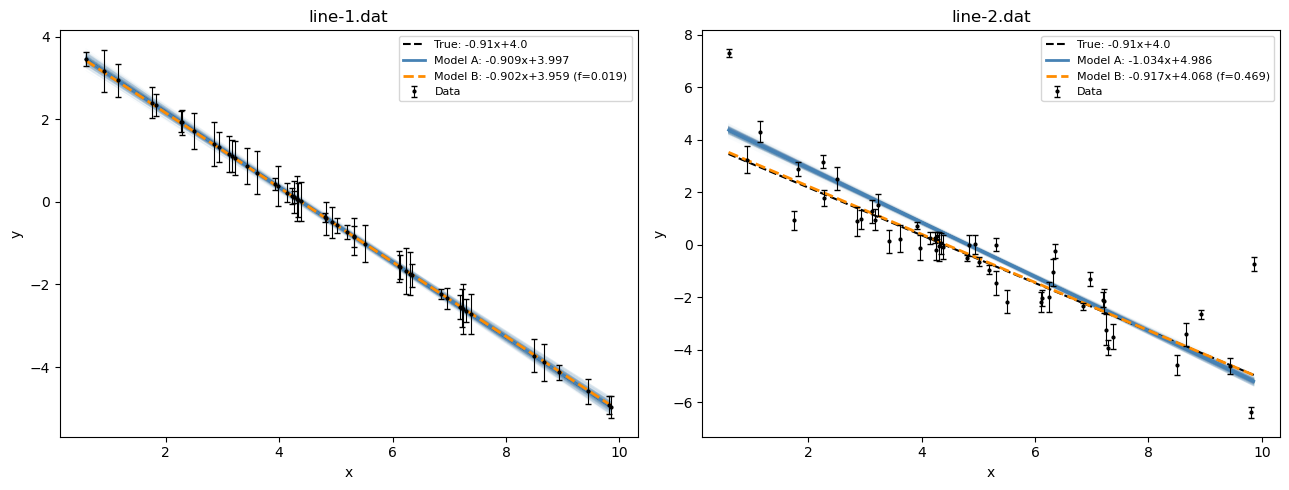

In [15]:
def plot_fit(ax, x, y, sig, med_A, med_B, samples_A, samples_B, title):
    xr = np.linspace(x.min(), x.max(), 200)
    # posterior predictive band (Model A, 1-sigma)
    idx = np.random.choice(len(samples_A), 300, replace=False)
    for s in samples_A[idx]:
        ax.plot(xr, s[0]*xr + s[1], color='steelblue', alpha=0.03, lw=0.8)
    ax.errorbar(x, y, yerr=sig, fmt='k.', ms=4, elinewidth=0.8,
                capsize=2, label='Data', zorder=5)
    ax.plot(xr, TRUE_M*xr + TRUE_B, 'k--', lw=1.5, label=f'True: {TRUE_M}x+{TRUE_B}')
    ax.plot(xr, med_A[0]*xr + med_A[1], color='steelblue', lw=2,
            label=f'Model A: {med_A[0]:.3f}x+{med_A[1]:.3f}')
    ax.plot(xr, med_B[0]*xr + med_B[1], color='darkorange', lw=2, ls='--',
            label=f'Model B: {med_B[0]:.3f}x+{med_B[1]:.3f} (f={med_B[2]:.3f})')
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_title(title); ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
plot_fit(axes[0], x1, y1, s1,
         (m1A, b1A), (m1B, b1B, f1B), samp1A, samp1B, 'line-1.dat')
plot_fit(axes[1], x2, y2, s2,
         (m2A, b2A), (m2B, b2B, f2B), samp2A, samp2B, 'line-2.dat')
plt.tight_layout()
plt.savefig('plots/fit_comparison.png', dpi=130, bbox_inches='tight')
plt.show()

## 7. Walker trajectories in parameter space

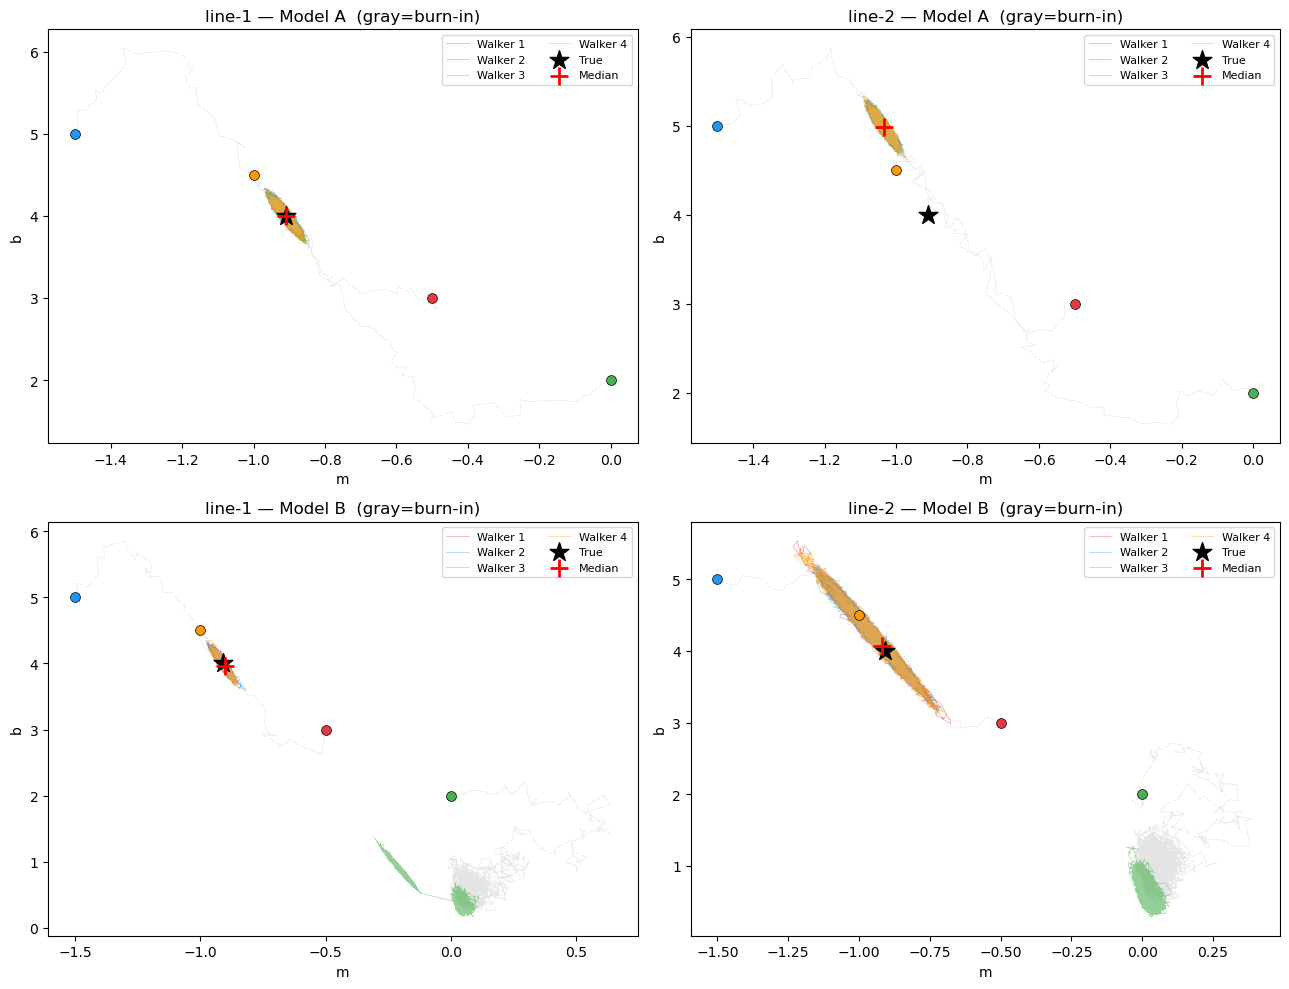

In [16]:
COLORS = ['#E63946', '#2196F3', '#4CAF50', '#FF9800']
BURNIN = 5_000

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for ax, chains, samp, med_m, med_b, title in [
    (axes[0,0], chains1A, samp1A, m1A, b1A, 'line-1 — Model A'),
    (axes[0,1], chains2A, samp2A, m2A, b2A, 'line-2 — Model A'),
    (axes[1,0], chains1B, samp1B, m1B, b1B, 'line-1 — Model B'),
    (axes[1,1], chains2B, samp2B, m2B, b2B, 'line-2 — Model B'),
]:
    for k, (c, col) in enumerate(zip(chains, COLORS)):
        ax.plot(c[:BURNIN, 0], c[:BURNIN, 1], color='lightgray', lw=0.4, alpha=0.6)
        ax.plot(c[BURNIN:, 0], c[BURNIN:, 1], color=col, lw=0.4, alpha=0.6,
                label=f'Walker {k+1}')
        ax.scatter(*c[0,:2], color=col, s=50, edgecolors='k', lw=0.5, zorder=5)
    ax.scatter(TRUE_M, TRUE_B, color='black', marker='*', s=200,
               zorder=10, label='True')
    ax.scatter(med_m, med_b, color='red', marker='+', s=150,
               linewidths=2, zorder=10, label='Median')
    ax.set_xlabel('m'); ax.set_ylabel('b')
    ax.set_title(title + '  (gray=burn-in)')
    ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig('plots/walkers.png', dpi=130, bbox_inches='tight')
plt.show()

## 8. Corner plots — marginal posteriors

--- line-1  Model A ---
  Median m = -0.9094
  Median b = 3.9966

Rango Percentil 16-84%:
 Param         16%    50% (median)         84%    84-16 (1σ)
  ----------------------------------------------------------
       m     -0.9255         -0.9094     -0.8932        0.0323
       b      3.9033          3.9966      4.0868        0.1835




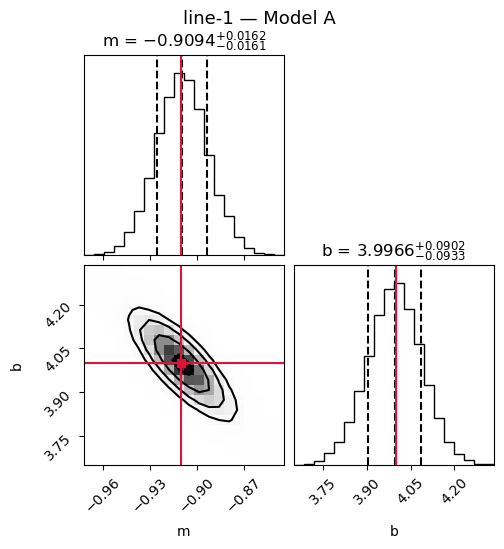

--- line-2  Model A ---
  Median m = -1.0341
  Median b = 4.9864

Rango Percentil 16-84%:
 Param         16%    50% (median)         84%    84-16 (1σ)
  ----------------------------------------------------------
       m     -1.0497         -1.0341     -1.0186        0.0311
       b      4.8973          4.9864      5.0738        0.1765




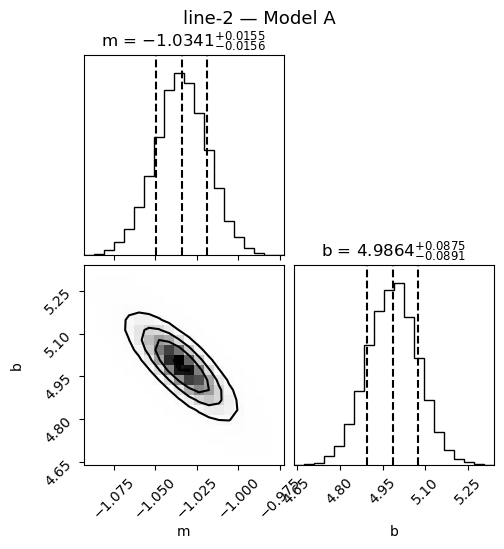

--- line-1  Model B ---
  Median m = -0.9023
  Median b = 3.9588
  Median f = 0.0195

Rango Percentil 16-84%:
 Param         16%    50% (median)         84%    84-16 (1σ)
  ----------------------------------------------------------
       m     -0.9229         -0.9023     -0.1858        0.7371
       b      0.8069          3.9588      4.0708        3.2639
       f      0.0051          0.0195      4.2899        4.2849




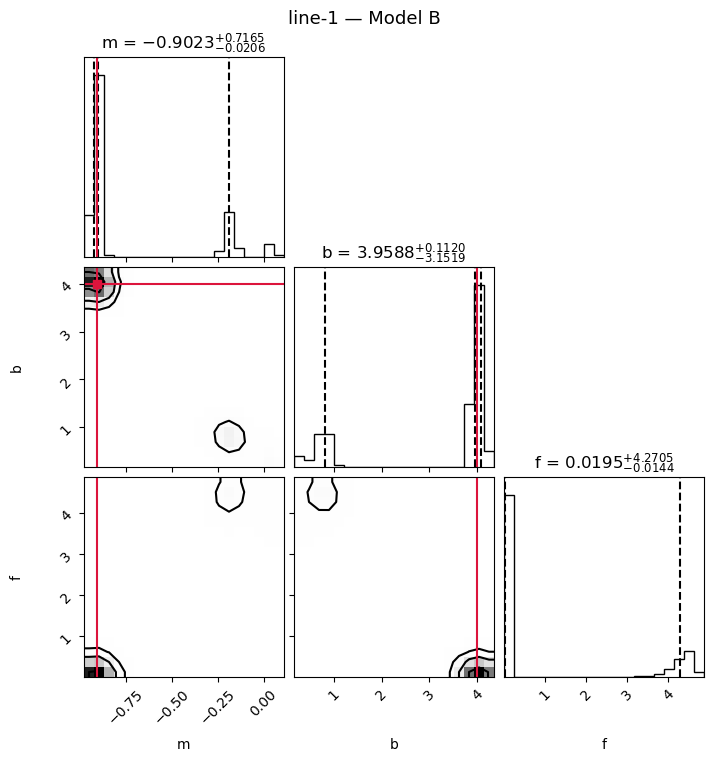

--- line-2  Model B ---
  Median m = -0.9174
  Median b = 4.0683
  Median f = 0.4685

Rango Percentil 16-84%:
 Param         16%    50% (median)         84%    84-16 (1σ)
  ----------------------------------------------------------
       m     -1.0049         -0.9174      0.0120        1.0169
       b      0.6019          4.0683      4.4646        3.8627
       f      0.3869          0.4685      3.7169        3.3300




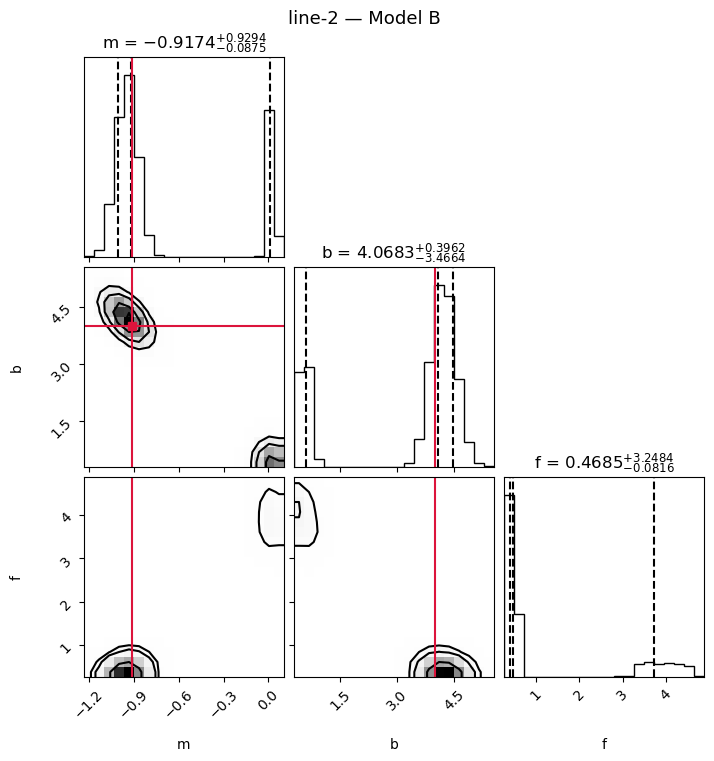

In [17]:
def make_corner(samples, labels, truths, title):
    medians = np.median(samples, axis=0)
    fig = corner.corner(
        samples, labels=labels, truths=truths,
        quantiles=[0.16, 0.5, 0.84],
        show_titles=True, title_fmt='.4f',
        truth_color='crimson',
        plot_datapoints=False,
        smooth=1.0,
    )
    fig.suptitle(title, y=1.01, fontsize=13)
    # Print medians
    for lbl, med in zip(labels, medians):
        print(f'  Median {lbl} = {med:.4f}')
    print('\nRango Percentil 16-84%:')
    print(f'{"Param":>6}  {"16%":>10}  {"50% (median)":>14}  {"84%":>10}  {"84-16 (1σ)":>12}')
    print(f'  {"-"*58}')
    for lbl, s in zip(labels, samples.T):
        p16, p50, p84 = np.percentile(s, [16, 50, 84])
        print(f'  {lbl:>6}  {p16:>10.4f}  {p50:>14.4f}  {p84:>10.4f}  {p84-p16:>12.4f}')
    print('\n')
    return fig

print('--- line-1  Model A ---')
fig1 = make_corner(samp1A, ['m', 'b'], [TRUE_M, TRUE_B], 'line-1 — Model A')
fig1.savefig('plots/corner_1A.png', dpi=120, bbox_inches='tight'); plt.show()

print('--- line-2  Model A ---')
fig2 = make_corner(samp2A, ['m', 'b'], [TRUE_M, TRUE_B], 'line-2 — Model A')
fig2.savefig('plots/corner_2A.png', dpi=120, bbox_inches='tight'); plt.show()

print('--- line-1  Model B ---')
fig3 = make_corner(samp1B, ['m', 'b', 'f'], [TRUE_M, TRUE_B, None], 'line-1 — Model B')
fig3.savefig('plots/corner_1B.png', dpi=120, bbox_inches='tight'); plt.show()

print('--- line-2  Model B ---')
fig4 = make_corner(samp2B, ['m', 'b', 'f'], [TRUE_M, TRUE_B, None], 'line-2 — Model B')
fig4.savefig('plots/corner_2B.png', dpi=120, bbox_inches='tight'); plt.show()

## 9. Summary table

In [13]:
print(f'True line: Y = {TRUE_M} X + {TRUE_B}')
print(f'{"":20} {"m":>10} {"b":>10} {"f":>10}')
print('-' * 52)
print(f'{"True":20} {TRUE_M:>10.4f} {TRUE_B:>10.4f} {"—":>10}')
print(f'{"line-1 Model A":20} {m1A:>10.4f} {b1A:>10.4f} {"—":>10}')
print(f'{"line-1 Model B":20} {m1B:>10.4f} {b1B:>10.4f} {f1B:>10.4f}')
print(f'{"line-2 Model A":20} {m2A:>10.4f} {b2A:>10.4f} {"—":>10}')
print(f'{"line-2 Model B":20} {m2B:>10.4f} {b2B:>10.4f} {f2B:>10.4f}')

True line: Y = -0.91 X + 4.0
                              m          b          f
----------------------------------------------------
True                    -0.9100     4.0000          —
line-1 Model A          -0.9094     3.9966          —
line-1 Model B          -0.9023     3.9588     0.0195
line-2 Model A          -1.0341     4.9864          —
line-2 Model B          -0.9174     4.0683     0.4685
